# GloVe Neural Network Training

## Author: Dr Partha Majumdar
#### ORC-ID: 0009-0002-7375-8034

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

# STEP 1: Define corpus

In [42]:
sentence = "I like orange juice and eat eggs daily"
tokens = sentence.split()

vocabulary = list(dict.fromkeys(tokens))   # preserve order
V = len(vocabulary)                        # vocabulary size
N = 3                                      # embedding dimension

word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for i, word in enumerate(vocabulary)}

print("STEP 1: Vocabulary")
print("Sentence:", sentence)
print("Tokens:", tokens)
print("Vocabulary:", vocabulary)
print("Vocabulary size V =", V)
print("Embedding dimension N =", N)

STEP 1: Vocabulary
Sentence: I like orange juice and eat eggs daily
Tokens: ['I', 'like', 'orange', 'juice', 'and', 'eat', 'eggs', 'daily']
Vocabulary: ['I', 'like', 'orange', 'juice', 'and', 'eat', 'eggs', 'daily']
Vocabulary size V = 8
Embedding dimension N = 3


# STEP 2: Build co-occurrence matrix X

In [43]:
def build_cooccurrence_matrix(tokens, word_to_index, window_size=2):
    """
    Build a word-word co-occurrence matrix using inverse-distance weighting.
    contribution = 1 / distance
    """
    V = len(word_to_index)
    X = np.zeros((V, V), dtype=np.float64)

    for center_pos, center_word in enumerate(tokens):
        center_idx = word_to_index[center_word]

        start = max(0, center_pos - window_size)
        end = min(len(tokens), center_pos + window_size + 1)

        for context_pos in range(start, end):
            if context_pos == center_pos:
                continue

            context_word = tokens[context_pos]
            context_idx = word_to_index[context_word]

            distance = abs(center_pos - context_pos)
            contribution = 1.0 / distance

            X[center_idx, context_idx] += contribution

    return X

window_size = 2
X = build_cooccurrence_matrix(tokens, word_to_index, window_size=window_size)

print("STEP 2: Co-occurrence Matrix X")
cooc_df = pd.DataFrame(X, index=vocabulary, columns=vocabulary)
print(cooc_df)

STEP 2: Co-occurrence Matrix X
          I  like  orange  juice  and  eat  eggs  daily
I       0.0   1.0     0.5    0.0  0.0  0.0   0.0    0.0
like    1.0   0.0     1.0    0.5  0.0  0.0   0.0    0.0
orange  0.5   1.0     0.0    1.0  0.5  0.0   0.0    0.0
juice   0.0   0.5     1.0    0.0  1.0  0.5   0.0    0.0
and     0.0   0.0     0.5    1.0  0.0  1.0   0.5    0.0
eat     0.0   0.0     0.0    0.5  1.0  0.0   1.0    0.5
eggs    0.0   0.0     0.0    0.0  0.5  1.0   0.0    1.0
daily   0.0   0.0     0.0    0.0  0.0  0.5   1.0    0.0


# STEP 3: Extract training pairs from nonzero entries of X

In [44]:
training_pairs = []

for i in range(V):
    for j in range(V):
        if X[i, j] > 0:
            training_pairs.append((i, j, X[i, j]))

print("STEP 3: Nonzero Training Pairs")
for i, j, x_ij in training_pairs:
    print(f"({index_to_word[i]:>6}, {index_to_word[j]:>6}) -> X_ij = {x_ij}")

print("\nTotal number of nonzero training pairs =", len(training_pairs))

STEP 3: Nonzero Training Pairs
(     I,   like) -> X_ij = 1.0
(     I, orange) -> X_ij = 0.5
(  like,      I) -> X_ij = 1.0
(  like, orange) -> X_ij = 1.0
(  like,  juice) -> X_ij = 0.5
(orange,      I) -> X_ij = 0.5
(orange,   like) -> X_ij = 1.0
(orange,  juice) -> X_ij = 1.0
(orange,    and) -> X_ij = 0.5
( juice,   like) -> X_ij = 0.5
( juice, orange) -> X_ij = 1.0
( juice,    and) -> X_ij = 1.0
( juice,    eat) -> X_ij = 0.5
(   and, orange) -> X_ij = 0.5
(   and,  juice) -> X_ij = 1.0
(   and,    eat) -> X_ij = 1.0
(   and,   eggs) -> X_ij = 0.5
(   eat,  juice) -> X_ij = 0.5
(   eat,    and) -> X_ij = 1.0
(   eat,   eggs) -> X_ij = 1.0
(   eat,  daily) -> X_ij = 0.5
(  eggs,    and) -> X_ij = 0.5
(  eggs,    eat) -> X_ij = 1.0
(  eggs,  daily) -> X_ij = 1.0
( daily,    eat) -> X_ij = 0.5
( daily,   eggs) -> X_ij = 1.0

Total number of nonzero training pairs = 26


# STEP 4: Initialise GloVe parameters

W       : word vectors

W_tilde : context vectors

b       : word biases

b_tilde : context biases


In [45]:
np.random.seed(42)

W = np.random.randn(V, N) * 0.01
W_tilde = np.random.randn(V, N) * 0.01
b = np.random.randn(V) * 0.01
b_tilde = np.random.randn(V) * 0.01

print("STEP 4: Initial Parameters")
print("W shape       =", W.shape)
print("W_tilde shape =", W_tilde.shape)
print("b shape       =", b.shape)
print("b_tilde shape =", b_tilde.shape)

print("\nInitial word vectors W")
print(pd.DataFrame(W, index=vocabulary, columns=[f"e{k+1}" for k in range(N)]))

print("\nInitial context vectors W_tilde")
print(pd.DataFrame(W_tilde, index=vocabulary, columns=[f"e{k+1}" for k in range(N)]))

print("\nWord bias vector b")
print(pd.DataFrame({"bias": b}, index=vocabulary))

print("\nContext bias vector b_tilde")
print(pd.DataFrame({"bias": b_tilde}, index=vocabulary))

STEP 4: Initial Parameters
W shape       = (8, 3)
W_tilde shape = (8, 3)
b shape       = (8,)
b_tilde shape = (8,)

Initial word vectors W
              e1        e2        e3
I       0.004967 -0.001383  0.006477
like    0.015230 -0.002342 -0.002341
orange  0.015792  0.007674 -0.004695
juice   0.005426 -0.004634 -0.004657
and     0.002420 -0.019133 -0.017249
eat    -0.005623 -0.010128  0.003142
eggs   -0.009080 -0.014123  0.014656
daily  -0.002258  0.000675 -0.014247

Initial context vectors W_tilde
              e1        e2        e3
I      -0.005444  0.001109 -0.011510
like    0.003757 -0.006006 -0.002917
orange -0.006017  0.018523 -0.000135
juice  -0.010577  0.008225 -0.012208
and     0.002089 -0.019597 -0.013282
eat     0.001969  0.007385  0.001714
eggs   -0.001156 -0.003011 -0.014785
daily  -0.007198 -0.004606  0.010571

Word bias vector b
            bias
I       0.003436
like   -0.017630
orange  0.003241
juice  -0.003851
and    -0.006769
eat     0.006117
eggs    0.010310
daily 

# STEP 5: Define weighting function f(x)

In [46]:
def glove_weight(x, x_max=100, alpha=0.75):
    if x == 0:
        return 0.0
    if x < x_max:
        return (x / x_max) ** alpha
    return 1.0

x_max = 100
alpha = 0.75

print("STEP 5: Weighting Function Hyperparameters")
print("x_max =", x_max)
print("alpha =", alpha)

STEP 5: Weighting Function Hyperparameters
x_max = 100
alpha = 0.75


# STEP 6: Forward pass for one training pair

In [47]:
def forward_pass(i, j, x_ij, W, W_tilde, b, b_tilde, x_max=100, alpha=0.75):
    """
    Compute forward pass for one GloVe pair (i, j).
    """
    w_i = W[i]                    # shape = (N,)
    w_tilde_j = W_tilde[j]        # shape = (N,)
    b_i = b[i]                    # scalar
    b_tilde_j = b_tilde[j]        # scalar

    dot_product = np.dot(w_i, w_tilde_j)
    prediction = dot_product + b_i + b_tilde_j
    log_xij = np.log(x_ij)
    weight = glove_weight(x_ij, x_max=x_max, alpha=alpha)

    residual = prediction - log_xij
    pair_loss = weight * (residual ** 2)

    cache = {
        "i": i,
        "j": j,
        "x_ij": x_ij,
        "w_i": w_i,
        "w_tilde_j": w_tilde_j,
        "b_i": b_i,
        "b_tilde_j": b_tilde_j,
        "dot_product": dot_product,
        "prediction": prediction,
        "log_xij": log_xij,
        "weight": weight,
        "residual": residual,
        "pair_loss": pair_loss
    }

    return pair_loss, cache

# STEP 7: Demonstrate one forward pass explicitly

In [48]:
target_word = "orange"
context_word = "juice"

i_demo = word_to_index[target_word]
j_demo = word_to_index[context_word]
x_demo = X[i_demo, j_demo]

demo_loss, demo_cache = forward_pass(
    i_demo, j_demo, x_demo,
    W, W_tilde, b, b_tilde,
    x_max=x_max, alpha=alpha
)

print("STEP 7: One Forward Pass Demonstration")
print("Target word  =", target_word)
print("Context word =", context_word)
print("X_ij         =", x_demo)
print("w_i          =", demo_cache["w_i"])
print("w_tilde_j    =", demo_cache["w_tilde_j"])
print("b_i          =", demo_cache["b_i"])
print("b_tilde_j    =", demo_cache["b_tilde_j"])
print("dot product  =", demo_cache["dot_product"])
print("prediction   =", demo_cache["prediction"])
print("log(X_ij)    =", demo_cache["log_xij"])
print("weight       =", demo_cache["weight"])
print("residual     =", demo_cache["residual"])
print("pair loss    =", demo_cache["pair_loss"])

STEP 7: One Forward Pass Demonstration
Target word  = orange
Context word = juice
X_ij         = 1.0
w_i          = [ 0.015792  0.007674 -0.004695]
w_tilde_j    = [-0.010577  0.008225 -0.012208]
b_i          = 0.00324083969394795
b_tilde_j    = 0.009755451271223592
dot product  = -4.659462993806404e-05
prediction   = 0.012949696335233478
log(X_ij)    = 0.0
weight       = 0.03162277660168379
residual     = 0.012949696335233478
pair loss    = 5.3029699854322805e-06


# STEP 8: Backpropagation for one training pair

In [49]:
def backward_pass(cache, W, W_tilde, b, b_tilde, learning_rate=0.05):
    """
    Compute gradients and update parameters for one GloVe pair.
    """
    i = cache["i"]
    j = cache["j"]
    weight = cache["weight"]
    residual = cache["residual"]
    w_i = cache["w_i"]
    w_tilde_j = cache["w_tilde_j"]

    # Pair loss:
    # J_ij = f(X_ij) * (prediction - log(X_ij))^2
    #
    # Let e = prediction - log(X_ij)
    # Then:
    # dJ/de = 2 * f(X_ij) * e

    grad_common = 2.0 * weight * residual   # scalar

    # Gradients
    d_w_i = grad_common * w_tilde_j         # shape = (N,)
    d_w_tilde_j = grad_common * w_i         # shape = (N,)
    d_b_i = grad_common                     # scalar
    d_b_tilde_j = grad_common               # scalar

    # Parameter updates
    W[i] -= learning_rate * d_w_i
    W_tilde[j] -= learning_rate * d_w_tilde_j
    b[i] -= learning_rate * d_b_i
    b_tilde[j] -= learning_rate * d_b_tilde_j

    return W, W_tilde, b, b_tilde

# STEP 9: Show one backward update explicitly

In [50]:
W_copy = W.copy()
W_tilde_copy = W_tilde.copy()
b_copy = b.copy()
b_tilde_copy = b_tilde.copy()

print("STEP 9: One Backward Pass Demonstration")
print("Before update:")
print("W[target]        =", W_copy[i_demo])
print("W_tilde[context] =", W_tilde_copy[j_demo])
print("b[target]        =", b_copy[i_demo])
print("b_tilde[context] =", b_tilde_copy[j_demo])

W_copy, W_tilde_copy, b_copy, b_tilde_copy = backward_pass(
    demo_cache, W_copy, W_tilde_copy, b_copy, b_tilde_copy, learning_rate=0.05
)

print("\nAfter update:")
print("W[target]        =", W_copy[i_demo])
print("W_tilde[context] =", W_tilde_copy[j_demo])
print("b[target]        =", b_copy[i_demo])
print("b_tilde[context] =", b_tilde_copy[j_demo])

STEP 9: One Backward Pass Demonstration
Before update:
W[target]        = [ 0.015792  0.007674 -0.004695]
W_tilde[context] = [-0.010577  0.008225 -0.012208]
b[target]        = 0.00324083969394795
b_tilde[context] = 0.009755451271223592

After update:
W[target]        = [ 0.015793  0.007674 -0.004694]
W_tilde[context] = [-0.010578  0.008225 -0.012208]
b[target]        = 0.003199889158521077
b_tilde[context] = 0.00971450073579672


# STEP 10: Compute total loss over all training pairs

In [51]:
def compute_total_loss(training_pairs, W, W_tilde, b, b_tilde, x_max=100, alpha=0.75):
    total_loss = 0.0

    for i, j, x_ij in training_pairs:
        pair_loss, _ = forward_pass(
            i, j, x_ij,
            W, W_tilde, b, b_tilde,
            x_max=x_max, alpha=alpha
        )
        total_loss += pair_loss

    return total_loss


initial_total_loss = compute_total_loss(
    training_pairs, W, W_tilde, b, b_tilde, x_max=x_max, alpha=alpha
)

print("STEP 10: Initial Total Loss")
print("Initial total loss =", initial_total_loss)

STEP 10: Initial Total Loss
Initial total loss = 0.10797151872537977


# STEP 11: Training loop

In [52]:
learning_rate = 0.05
epochs = 500
loss_history = []

print("\nSTEP 11: Training Starts")

for epoch in range(1, epochs + 1):
    total_loss = 0.0

    for i, j, x_ij in training_pairs:
        pair_loss, cache = forward_pass(
            i, j, x_ij,
            W, W_tilde, b, b_tilde,
            x_max=x_max, alpha=alpha
        )

        total_loss += pair_loss

        W, W_tilde, b, b_tilde = backward_pass(
            cache, W, W_tilde, b, b_tilde,
            learning_rate=learning_rate
        )

    avg_loss = total_loss / len(training_pairs)
    loss_history.append(avg_loss)

    if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
        print(f"Epoch {epoch:>3} | Average Pair Loss = {avg_loss:.6f}")


STEP 11: Training Starts
Epoch   1 | Average Pair Loss = 0.004143
Epoch  50 | Average Pair Loss = 0.002968
Epoch 100 | Average Pair Loss = 0.002744
Epoch 150 | Average Pair Loss = 0.002688
Epoch 200 | Average Pair Loss = 0.002663
Epoch 250 | Average Pair Loss = 0.002648
Epoch 300 | Average Pair Loss = 0.002638
Epoch 350 | Average Pair Loss = 0.002630
Epoch 400 | Average Pair Loss = 0.002624
Epoch 450 | Average Pair Loss = 0.002619
Epoch 500 | Average Pair Loss = 0.002616


# STEP 12: Plot loss curve

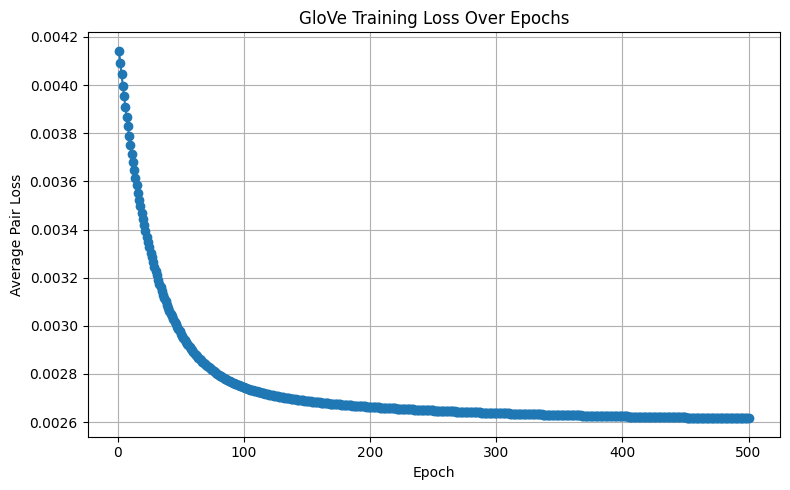

In [53]:
epochs_range = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Pair Loss")
plt.title("GloVe Training Loss Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 13: Show learned parameters

In [54]:
print("STEP 13: Learned Word Vectors W")
print(pd.DataFrame(W, index=vocabulary, columns=[f"e{k+1}" for k in range(N)]))

print("\nSTEP 13: Learned Context Vectors W_tilde")
print(pd.DataFrame(W_tilde, index=vocabulary, columns=[f"e{k+1}" for k in range(N)]))

print("\nSTEP 13: Learned Word Biases b")
print(pd.DataFrame({"bias": b}, index=vocabulary))

print("\nSTEP 13: Learned Context Biases b_tilde")
print(pd.DataFrame({"bias": b_tilde}, index=vocabulary))

STEP 13: Learned Word Vectors W
              e1        e2        e3
I       0.008510 -0.011601  0.006089
like    0.017518 -0.001855  0.002883
orange  0.015209  0.020582  0.000863
juice   0.000767 -0.003585 -0.013647
and     0.002078 -0.023465 -0.014614
eat     0.001835 -0.022289 -0.006482
eggs   -0.011426 -0.002330  0.028843
daily  -0.003306 -0.000715 -0.019402

STEP 13: Learned Context Vectors W_tilde
              e1        e2        e3
I      -0.007774 -0.004735 -0.010699
like    0.007880 -0.001895  0.002263
orange -0.004168  0.027447  0.000466
juice  -0.010971  0.013148 -0.018390
and     0.001527 -0.028679 -0.026969
eat     0.000154 -0.001453  0.010678
eggs   -0.003484  0.003329 -0.011160
daily  -0.008872 -0.000407  0.015986

STEP 13: Learned Word Biases b
            bias
I      -0.172947
like   -0.010652
orange -0.154211
juice  -0.133958
and    -0.133813
eat    -0.151863
eggs   -0.004776
daily  -0.168600

STEP 13: Learned Context Biases b_tilde
            bias
I      -0.172681


# STEP 14: Construct final embeddings

A common practice in GloVe is to combine the word and context vectors:

final_embedding = W + W_tilde

In [55]:
final_embeddings = W + W_tilde

print("STEP 14: Final Combined Embeddings (W + W_tilde)")
final_embedding_df = pd.DataFrame(
    final_embeddings,
    index=vocabulary,
    columns=[f"e{k+1}" for k in range(N)]
)
print(final_embedding_df)

STEP 14: Final Combined Embeddings (W + W_tilde)
              e1        e2        e3
I       0.000736 -0.016335 -0.004610
like    0.025399 -0.003749  0.005146
orange  0.011041  0.048029  0.001329
juice  -0.010204  0.009563 -0.032037
and     0.003605 -0.052143 -0.041583
eat     0.001989 -0.023742  0.004196
eggs   -0.014909  0.000998  0.017683
daily  -0.012178 -0.001122 -0.003417


# STEP 15: Word Embedding Visualisation

After training, the GloVe model represents each word as a vector in a continuous embedding space. In our example, the embedding dimension has been intentionally set to three, allowing us to directly visualise the learned representations without any dimensionality reduction. This provides a rare and valuable opportunity to observe how semantic relationships emerge geometrically. Words that share similar contexts tend to occupy nearby regions in space, while unrelated words drift apart. The following 3D visualisation transforms abstract numerical vectors into an interpretable spatial structure, offering an intuitive understanding of how GloVe encodes meaning.

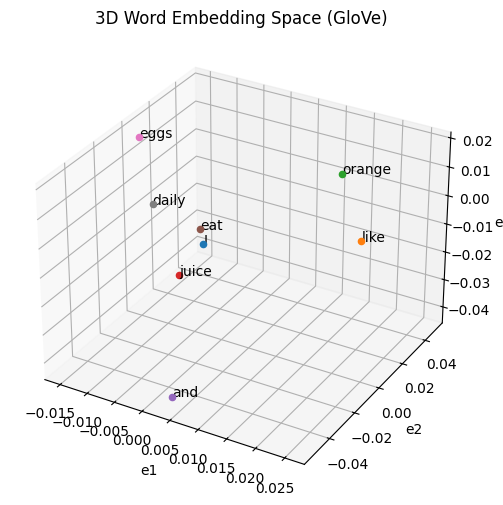

In [56]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for word, vec in zip(vocabulary, final_embeddings):
    x, y, z = vec
    ax.scatter(x, y, z)
    ax.text(x, y, z, word)

ax.set_xlabel("e1")
ax.set_ylabel("e2")
ax.set_zlabel("e3")

ax.set_title("3D Word Embedding Space (GloVe)")
plt.show()

# STEP 16: Evaluate one pair after training

In [57]:
final_demo_loss, final_demo_cache = forward_pass(
    i_demo, j_demo, x_demo,
    W, W_tilde, b, b_tilde,
    x_max=x_max, alpha=alpha
)

print("STEP 16: Re-evaluate One Pair After Training")
print("Target word  =", target_word)
print("Context word =", context_word)
print("X_ij         =", x_demo)
print("Prediction   =", final_demo_cache["prediction"])
print("log(X_ij)    =", final_demo_cache["log_xij"])
print("Residual     =", final_demo_cache["residual"])
print("Pair loss    =", final_demo_cache["pair_loss"])

STEP 16: Re-evaluate One Pair After Training
Target word  = orange
Context word = juice
X_ij         = 1.0
Prediction   = -0.29023932903355654
log(X_ij)    = 0.0
Residual     = -0.29023932903355654
Pair loss    = 0.0026638669076694452


# STEP 17: Evaluate all training pairs after training

In [58]:
rows = []

for i, j, x_ij in training_pairs:
    pair_loss, cache = forward_pass(
        i, j, x_ij,
        W, W_tilde, b, b_tilde,
        x_max=x_max, alpha=alpha
    )

    rows.append({
        "Target": index_to_word[i],
        "Context": index_to_word[j],
        "X_ij": x_ij,
        "log(X_ij)": cache["log_xij"],
        "Prediction": cache["prediction"],
        "Residual": cache["residual"],
        "Weight": cache["weight"],
        "Pair Loss": pair_loss
    })

evaluation_df = pd.DataFrame(rows)

print("\nSTEP 17: Final Evaluation on All Nonzero Training Pairs")
print(evaluation_df)


STEP 17: Final Evaluation on All Nonzero Training Pairs
    Target Context  X_ij  log(X_ij)  Prediction  Residual    Weight  Pair Loss
0        I    like   1.0   0.000000   -0.183622 -0.183622  0.031623   0.001066
1        I  orange   0.5  -0.693147   -0.328232  0.364915  0.018803   0.002504
2     like       I   1.0   0.000000   -0.183491 -0.183491  0.031623   0.001065
3     like  orange   1.0   0.000000   -0.165708 -0.165708  0.031623   0.000868
4     like   juice   0.5  -0.693147   -0.147038  0.546109  0.018803   0.005608
5   orange       I   0.5  -0.693147   -0.327117  0.366031  0.018803   0.002519
6   orange    like   1.0   0.000000   -0.164905 -0.164905  0.031623   0.000860
7   orange   juice   1.0   0.000000   -0.290239 -0.290239  0.031623   0.002664
8   orange     and   0.5  -0.693147   -0.293099  0.400048  0.018803   0.003009
9    juice    like   0.5  -0.693147   -0.144754  0.548393  0.018803   0.005655
10   juice  orange   1.0   0.000000   -0.289000 -0.289000  0.031623   0.00

In [59]:
# ============================================================
# STEP 18: Compact summary
# ============================================================
print("STEP 18: Final Summary")
print("GloVe uses the co-occurrence matrix as its training signal.")
print("For each nonzero pair (i, j), the model tries to make")
print("w_i^T w_tilde_j + b_i + b_tilde_j approximate log(X_ij).")
print("Training gradually updates the word vectors, context vectors, and biases")
print("so that the weighted regression loss becomes smaller.")
print("The final embedding of a word is often taken as W + W_tilde.")

STEP 18: Final Summary
GloVe uses the co-occurrence matrix as its training signal.
For each nonzero pair (i, j), the model tries to make
w_i^T w_tilde_j + b_i + b_tilde_j approximate log(X_ij).
Training gradually updates the word vectors, context vectors, and biases
so that the weighted regression loss becomes smaller.
The final embedding of a word is often taken as W + W_tilde.
